<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
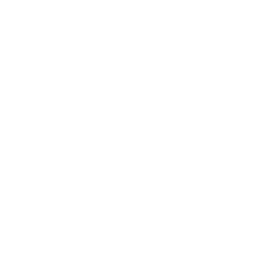
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Market Regime Identification</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Quantitative Finance / Asset Management &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This example uses **PROC ACECLUS** to find the latent structure that separates market regimes, then clusters on it. From 100 weekly observations of 10 market features (equity return and volatility, credit and high-yield spreads, the 2y/10y curve, the dollar, commodities, and a VIX change), ACECLUS estimates an approximate within-regime covariance *without* using any regime label, and derives canonical variables along which the regimes pull apart.

At the P=0.02 threshold the algorithm converges in two iterations and retains **three canonical dimensions**, which together account for all of the between-regime spread (eigenvalue proportions 57.8%, 24.4%, 17.8%). A looser P=0.05 threshold over-smooths the covariance and **collapses the structure to a single dimension** — a useful caution that the threshold materially shapes the result.

Feeding the three canonical variables into **PROC FASTCLUS** (k=4) yields a clean stress-severity ordering of the 100 weeks (overall R² = 0.51, pseudo F = 33.2): a 62-week calm core, a 22-week recovering/easing-volatility group, a 12-week elevated-stress group, and a 4-week deep-crisis group with high-yield spreads averaging ~1,514 bps. These assignments are exported for downstream portfolio-risk conditioning.


## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Weekly market feature observations across asset classes | 100 |
| Variables: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

The series is generated by a five-state Markov regime-switching process (bull expansion, late cycle, risk-off, crisis, recovery) with regime-conditional feature distributions. The DATA step generates the first 100 weekly observations (~2 years) — a bull-dominated window that also visits a short crisis and recovery. Weekly returns and level changes stand in for end-of-week price moves; spreads are in basis points and volatility is a VIX-style index.


---

In [1]:
/* --------------------------------------------------------
   Generate a weekly multi-asset market history with five
   embedded regime states driven by a Markov switching
   process. The feature table covers the first 100 weekly
   observations (~2 years) -- a bull-dominated window
   punctuated by a short crisis and recovery.
   -------------------------------------------------------- */
data work.market_weekly;
    call streaminit(42);
    /* 5 regimes: 1=Bull, 2=Late-Cycle, 3=Risk-Off, 4=Crisis, 5=Recovery */
    array regime_names[5] $16 _temporary_
        ('BULL_EXPANSION' 'LATE_CYCLE' 'RISK_OFF_FLIGHT'
         'CRISIS' 'RECOVERY');
    retain current_regime 1;
    do week_id = 1 to 100;
        /* Markov regime switching */
        u = rand('uniform');
        if current_regime = 1 then do; /* Bull: long-lived */
            if u > 0.97 then current_regime = 2;
        end;
        else if current_regime = 2 then do; /* Late-cycle */
            if u > 0.92 then current_regime = 3;
        end;
        else if current_regime = 3 then do; /* Risk-off */
            if u > 0.80 then current_regime = 4;
            else if u < 0.10 then current_regime = 1;
        end;
        else if current_regime = 4 then do; /* Crisis: short */
            if u > 0.75 then current_regime = 5;
        end;
        else if current_regime = 5 then do; /* Recovery */
            if u > 0.85 then current_regime = 1;
        end;
        regime_label = regime_names[current_regime];
        /* Regime-conditional feature distributions */
        if current_regime = 1 then do;  /* Bull */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        end;
        else if current_regime = 2 then do;  /* Late-cycle */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        end;
        else if current_regime = 3 then do;  /* Risk-off */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        end;
        else if current_regime = 4 then do;  /* Crisis */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        end;
        else do;  /* Recovery */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        end;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        if week_id = 1 then vix_chg = 0;
        output;
    end;
    drop u;
    rename credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
run;

NOTE: DATA work.market_weekly


NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline market feature distributions by regime
   -------------------------------------------------------- */
proc means data=work.market_weekly n mean std min max;
    class regime_label;
    var eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
run;

                                                  The MEANS Procedure

                                           Analysis Variable : eq_return_pct

        regime_label             N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------
        BULL_EXPANSION              28      0.2860000      1.0226518     -1.5980000      2.2150000
        CRISIS                      12     -2.3403333      3.9436692     -8.0160000      3.7360000
        LATE_CYCLE                  39      0.0364359      1.9733801     -4.6010000      3.7030000
        RECOVERY                     4      0.0077500      1.5951747     -0.8330000      2.4000000
        RISK_OFF_FLIGHT             17     -0.8447059      1.2832441     -3.3850000      1.1810000
        ------------------------------------------------------------------------------------------

                                             Analysis Vari

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


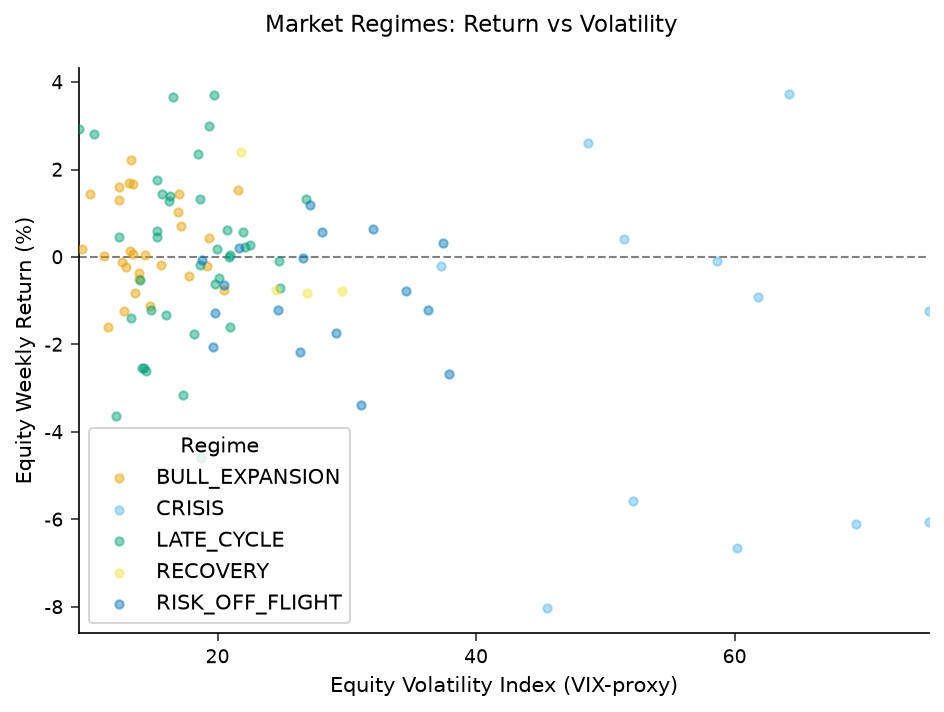

In [3]:
/* --------------------------------------------------------
   Equity return vs volatility index by regime label
   -------------------------------------------------------- */
proc sgplot data=work.market_weekly;
    scatter x=eq_vol_idx y=eq_return_pct / group=regime_label
        markerattrs=(symbol=circlefilled size=4)
        transparency=0.55;
    refline 0 / axis=y lineattrs=(color=gray pattern=dash);
    xaxis label='Equity Volatility Index (VIX-proxy)';
    yaxis label='Equity Weekly Return (%)';
    keylegend / title='Regime';
    title 'Market Regimes: Return vs Volatility';
run;

---

In [4]:
/* --------------------------------------------------------
   Approximate within-regime covariance estimation.
   ACECLUS estimates the pooled within-cluster covariance
   without knowing the cluster labels, then derives
   canonical variables that separate the regimes. P=0.02
   sets the pairwise-distance threshold: only the closest
   ~2% of observation pairs are treated as same-regime.
   -------------------------------------------------------- */
proc aceclus data=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    var eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
run;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0

NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   Sensitivity check at P=0.05 -- a looser same-regime
   threshold pulls in more pairs, inflating the estimated
   within-regime covariance. Compare the canonical
   structure (eigenvalues and retained dimensions) against
   the P=0.02 solution.
   -------------------------------------------------------- */
proc aceclus data=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    var eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
run;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0

NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   k-means on the ACECLUS canonical variables. ACECLUS
   retained three canonical dimensions (Can1-Can3), so the
   clustering runs on those. Four clusters target the four
   well-populated market states.
   -------------------------------------------------------- */
proc fastclus data=work.regime_canonical
              maxclusters=4
              maxiter=100
              converge=0.0001
              out=work.regime_assignments
              outstat=work.regime_stats;
    var can1 can2 can3;
run;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4                   4         1.7742             4.0619              2         4.1923

                                    

NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                         Regime Cluster vs Actual Regime Label                                          

                                                   The FREQ Procedure

Table of CLUSTER by REGIME_LABEL

CLUSTER | BULL_EXPANSION |         CRISIS |     LATE_CYCLE |       RECOVERY |RISK_OFF_FLIGHT |           Total
--------+----------------+----------------+----------------+----------------+----------------+----------------
1       |              2 |              4 |              2 |              0 |              4 |              12
        |           2.00 |           4.00 |           2.00 |           0.00 |           4.00 |           12.00
--------+----------------+----------------+----------------+----------------+----------------+----------------
2       |             21 |              3 |             28 |              3 |              7 |              62
        |          21.00 |           3.00 |          28.00 |           3.00 |           7.00 |           62

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


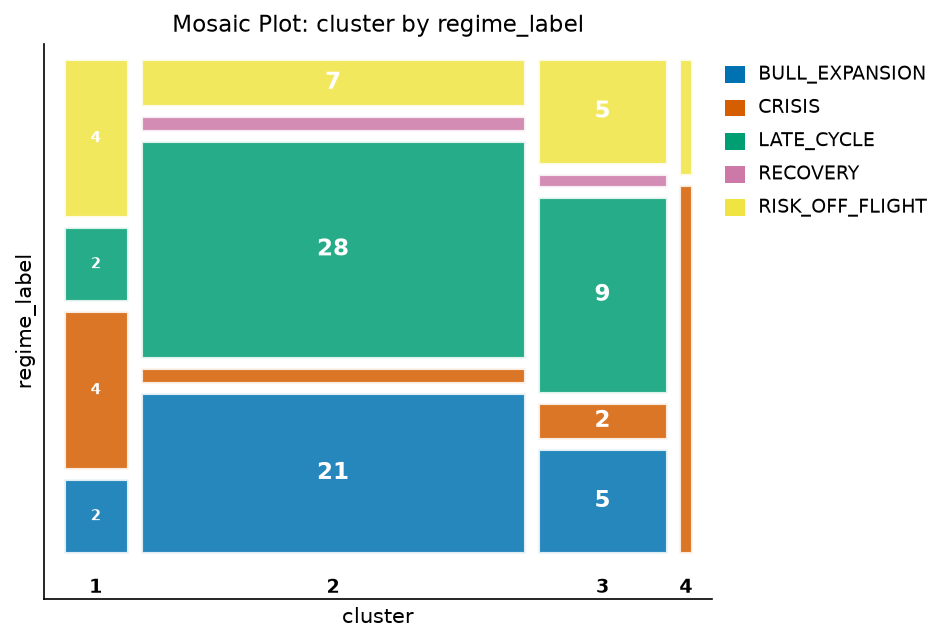

In [7]:
/* --------------------------------------------------------
   Validate assigned clusters against known
   regime labels from data generation
   -------------------------------------------------------- */
proc freq data=work.regime_assignments;
    tables cluster * regime_label / norow nocol;
    title 'Regime Cluster vs Actual Regime Label';
run;

In [8]:
/* --------------------------------------------------------
   Profile regime feature means for interpretation
   -------------------------------------------------------- */
proc means data=work.regime_assignments mean;
    class cluster;
    var eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
run;

                                         Regime Cluster vs Actual Regime Label                                          

                                                  The MEANS Procedure

                                           Analysis Variable : eq_return_pct

                              N
        CLUSTER             Obs           Mean
        --------------------------------------
        1                    12     -2.0955000
        2                    62     -0.3638871
        3                    22      0.7421364
        4                     4     -0.4010000
        --------------------------------------

                                             Analysis Variable : eq_vol_idx

                              N
        CLUSTER             Obs           Mean
        --------------------------------------
        1                    12     39.0125000
        2                    62     20.3977419
        3                    22     20.4918182
        4              

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interpretation

**ACECLUS canonical structure.** On the 100-week sample, PROC ACECLUS (P=0.02, threshold = 2.578941) converged in two iterations and produced three canonical variables. Their eigenvalues of `Inv(ACE)*(COV-ACE)` are 0.0219, 0.0093 and 0.0067, i.e. proportions of 57.8%, 24.4% and 17.8% (cumulative 100%). The first canonical axis carries the dominant risk-on/risk-off contrast; the second and third refine it. Because the equity-volatility and spread features are strongly comoving, ACECLUS folds that shared variation into the within-regime covariance so the canonical axes reflect genuine between-regime separation rather than common scale.

**Threshold sensitivity.** Re-running at P=0.05 raises the distance threshold to 2.899704, which pulls 4,949 of the 4,950 observation pairs inside the cutoff. The estimated within-regime covariance then nearly equals the total covariance, and the canonical structure **collapses to a single dimension** (one eigenvalue, 0.0096, at 100%). The P=0.02 and P=0.05 solutions are therefore *not* interchangeable here — a looser threshold erases the finer regime axes, so the tighter threshold is the more informative specification for this sample.

**Clustering on the canonical variables.** PROC FASTCLUS (k=4) on Can1–Can3 gives an overall R² of 0.5089 and a pseudo F of 33.16. Can2 does most of the separating work (R² = 0.626), Can1 contributes moderately (R² = 0.359), and Can3 adds essentially nothing (R² = 0.000) — consistent with only two axes carrying strong signal. The four clusters line up as a market-stress gradient:

| Cluster | n | Mean Eq Return | Mean VIX | Mean HY Spread | Mean VIX Change | Reading |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0.36% | 20.4 | 534 bps | +1.2 | Calm core (bull / late-cycle) |
| 3 | 22 | +0.74% | 20.5 | 539 bps | -9.6 | Recovering, volatility falling |
| 1 | 12 | -2.10% | 39.0 | 720 bps | +11.3 | Elevated stress, volatility spiking |
| 4 |  4 | -0.40% | 47.4 | 1,514 bps | +0.1 | Deep crisis, extreme credit stress |

**Cluster vs. true regime.** The crosstab shows the clusters do not map one-to-one onto the five generating labels — expected, because the labels overlap heavily in feature space at this sample size. The large calm cluster (62) absorbs most bull (21) and late-cycle (28) weeks; the deep-crisis cluster (4) is almost entirely the most extreme crisis weeks (3 of 4). The canonical axes thus organize the weeks by *severity*, not by exact label, which is the more actionable signal for risk conditioning.

**Use.** The exported weekly assignments support tactical conditioning: lighten risk and extend duration as weeks migrate toward Clusters 1 and 4, and re-risk as they return to the calm core (Cluster 2) or the recovering group (Cluster 3).


---

In [9]:
/* --------------------------------------------------------
   Export weekly regime assignments for portfolio
   risk model conditioning and signal generation
   -------------------------------------------------------- */
proc export data=work.regime_assignments
    outfile='market_regime_assignments.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>